In [888]:

from __future__ import annotations
import operator
from pathlib import Path
from pydantic import BaseModel, Field, field_validator
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from typing import TypedDict, List, Annotated, Literal, Optional  # Literal add kiya
from google.genai import interactions
from langchain_community.tools.tavily_search import TavilySearchResults
import os
import time, requests
from langchain_groq import ChatGroq
import json
from datetime import date


In [889]:
# ──────────────────────────────────────────
# 1) Schemas
# ──────────────────────────────────────────

class Task(BaseModel):
    id: int
    title: str
    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: Annotated[List[str], Field(min_length=3, max_length=6)] = Field(
        ...,
        description="3-6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ..., description="Target word count for this section (120-550)."
    )
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False
    @field_validator("bullets", mode="before")
    @classmethod
    def ensure_min_bullets(cls, v: list) -> list:
        if isinstance(v, list):
            while len(v) < 3:
                v.append("Explore additional aspects of this topic in depth.")
        return v


class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]


class EvidenceItem(BaseModel):
    title: Optional[str] = None
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None

    @field_validator("title", mode="before")
    @classmethod
    def fallback_title(cls, v, info):
        if v:
            return v
        url = info.data.get("url", "")
        return url or "Untitled"


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)

response = llm.invoke(
    """
Return ONLY valid JSON.

Schema:
{
  "needs_research": true,
  "mode": "hybrid",
  "queries": ["query"]
}

Topic: state of multimodal LLMs in 2026
"""
)

print(response.content)

In [890]:
class State(TypedDict):
    topic: str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    as_of: str
    recency_days: int
    sections: Annotated[List[tuple[str]], operator.add]
    merged_md: str
    md_with_placeholders: str
    image_specs: List[dict]
    final: str

In [891]:
from langchain_cerebras import ChatCerebras

load_dotenv()
llm = ChatCerebras(
    model="gpt-oss-120b",  # ← abhi available
    temperature=0.3,
    cerebras_api_key=os.environ["CEREBRAS_API_KEY"]
)


print("LLM ready! ✅")

LLM ready! ✅


In [892]:
import json

ROUTER_SYSTEM = """
Return ONLY valid JSON.

Schema:
{
  "needs_research": boolean,
  "mode": "closed_book|hybrid|open_book",
  "queries": ["query1", "query2"]
}

No markdown.
No explanations.
No extra keys.
"""

def router_node(state: State) -> dict:
    print("=" * 80)
    print("ROUTER NODE VERSION 2026-06-20")
    print("TOPIC:", state["topic"])
    print("=" * 80)

    topic = state["topic"]

    response = llm.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(
                content=f"Topic: {topic}"
            ),
        ]
    )

    print("RAW RESPONSE:")
    print(response.content)

    data = json.loads(response.content)

    decision = RouterDecision.model_validate(data)

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

In [893]:
# ──────────────────────────────────────────
# 4) Research (Tavily)
# ──────────────────────────────────────────

def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        snippet = r.get("content") or r.get("snippet") or ""
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": snippet[:300],   
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])[:2]
    max_results = 3

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    response = llm.invoke(
        [
        SystemMessage(
            content=RESEARCH_SYSTEM +
            "\nReturn ONLY valid JSON matching EvidencePack."
        ),
        HumanMessage(
            content=f"Raw results:\n{json.dumps(raw_results[:5])}"
        ),
        ]
    )
    raw = response.content.strip()

    if raw.startswith("```"):
        raw = raw.replace("```json", "")
        raw = raw.replace("```", "")
        raw = raw.strip()

    pack = EvidencePack.model_validate_json(raw)

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
       if e.url:
        dedup[e.url] = e

    return {"evidence": list(dedup.values())}


In [894]:
# ──────────────────────────────────────────
# 5) Orchestrator (Plan)
# ──────────────────────────────────────────

ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5-9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3-6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120-550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

import json
ORCH_SYSTEM_JSON = (
    ORCH_SYSTEM
    + "\n\nIMPORTANT: You must respond with a single valid JSON object only. "
      "Do not include markdown fences, comments, or any text outside the JSON object. "
      "The JSON object must match this schema:\n"
    + json.dumps(Plan.model_json_schema())
)

def orchestrator_node(state: State) -> dict:
    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    planner = llm.with_structured_output(Plan, method="json_mode")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM_JSON),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Respond with JSON only.\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )
    return {"plan": plan}

In [895]:
# ──────────────────────────────────────────
# 6) Fanout
# ──────────────────────────────────────────

def fanout(state: State) -> dict:
    all_sections = []
    
    for task in state["plan"].tasks:
        print(f"[Worker {task.id}] Writing: {task.title}...")
        
        payload = {
            "task": task.model_dump(),
            "topic": state["topic"],
            "mode": state["mode"],
            "plan": state["plan"].model_dump(),
            "evidence": [e.model_dump() for e in state.get("evidence", [])],
        }
        
        result = worker(payload)  # ← direct call, no Send()
        all_sections.append(result["sections"][0])  # (task.id, section_md)
        
        print(f"[Worker {task.id}] Done ✓")
        time.sleep(4)  # TPM limit avoid karo
    
    return {"sections": all_sections}

In [896]:
def worker(payload: dict) -> dict:

    # payload contains what we sent (as dicts from fanout) — rebuild as objects
    task = Task(**payload["task"])
    topic = payload["topic"]
    plan = Plan(**payload["plan"])

    bullets_text = "\n-" + "\n-".join(task.bullets)

    section_md = llm.invoke(
        [
            SystemMessage(
                content=(
                    "You are a senior technical writer and developer advocate. Write ONE section of a technical blog post in Markdown.\n"
                    "Hard constraints:\n"
                    "- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).\n"
                    "- Stay close to the Target words (±15%).\n"
                    "- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).\n\n"
                    "Technical quality bar:\n"
                    "- Be precise and implementation-oriented (developers should be able to apply it).\n"
                    "- Prefer concrete details over abstractions: APIs, data structures, protocols, and exact terms.\n"
                    "- When relevant, include at least one of:\n"
                    "  * a small code snippet (minimal, correct, and idiomatic)\n"
                    "  * a tiny example input/output\n"
                    "  * a checklist of steps\n"
                    "  * a diagram described in text (e.g., 'Flow: A -> B -> C')\n"
                    "- Explain trade-offs briefly (performance, cost, complexity, reliability).\n"
                    "- Call out edge cases / failure modes and what to do about them.\n"
                    "- If you mention a best practice, add the 'why' in one sentence.\n\n"
                    "Markdown style:\n"
                    "- Start with a '## <Section Title>' heading.\n"
                    "- Use short paragraphs, bullet lists where helpful, and code fences for code.\n"
                    "- Avoid fluff. Avoid marketing language.\n"
                    "- If you include code, keep it focused on the bullet being addressed.\n"
                )
            ),
            HumanMessage(
                content=(
                    f"Blog: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Bullets: {bullets_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [897]:
# ========================================
# 8) ReducerWithImages (subgraph)
#    merge_content -> decide_images -> generate_and_place_images
# ========================================

def merge_content(state: State) -> dict:
    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    return {"merged_md": merged_md}


import json

DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
"""

DECIDE_IMAGES_SYSTEM_JSON = (
    DECIDE_IMAGES_SYSTEM
    + """

IMPORTANT: Respond with a single valid JSON object only.
No markdown fences, no comments, no extra text.

Required JSON structure:
{
  "md_with_placeholders": "<complete blog markdown with [[IMAGE_N]] placeholders inserted>",
  "images": [
    {
      "placeholder": "[[IMAGE_1]]",
      "filename": "images/example.png",
      "alt": "Alt text here",
      "caption": "Caption here",
      "prompt": "Detailed image generation prompt",
      "size": "1536x1024",
      "quality": "medium"
    }
  ]
}
"""
)


def decide_images(state: State) -> dict:

    planner = llm.with_structured_output(GlobalImagePlan, method="json_mode")
    merged_md = state["merged_md"]
    plan = state["plan"]
    assert plan is not None

    image_plan = planner.invoke(
        [
            SystemMessage(content=DECIDE_IMAGES_SYSTEM_JSON),
            HumanMessage(
                content=(
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Topic: {state['topic']}\n\n"
                    "Insert placeholders + propose image prompts. Respond with JSON only.\n\n"
                    f"{merged_md}"
                )
            ),
        ]
    )

    return {
        "md_with_placeholders": image_plan.md_with_placeholders,
        "image_specs": [img.model_dump() for img in image_plan.images],
    }


# ✅ NAYA — yeh daalo
def _generate_image_bytes(prompt: str) -> bytes:
    api_key = os.environ.get("HF_API_KEY")
    if not api_key:
        raise RuntimeError("HF_API_KEY is not set.")

    MODELS = [
        "black-forest-labs/FLUX.1-schnell",
        "stabilityai/stable-diffusion-3.5-large-turbo",
    ]
    
    last_error = None
    for model in MODELS:
        try:
            response = requests.post(
                f"https://router.huggingface.co/hf-inference/models/{model}",
                headers={
                    "Authorization": f"Bearer {api_key}",
                    "Content-Type": "application/json"
                },
                json={"inputs": prompt},
                timeout=120,
            )
            if response.status_code == 200:
                return response.content
            last_error = f"{model}: {response.status_code} - {response.text}"
        except Exception as e:
            last_error = str(e)
    
    raise RuntimeError(f"All models failed. Last error: {last_error}")

def generate_and_place_images(state: State) -> dict:

    plan = state["plan"]
    assert plan is not None

    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    # If no images requested, just write merged markdown
    if not image_specs:
        filename = f"{plan.blog_title}.md"
        Path(filename).write_text(md, encoding="utf-8")
        return {"final": md}

    images_dir = Path("images")
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        
        # ✅ NAYA — double images/ fix
        clean_filename = filename.replace("images/", "").replace("images\\", "")
        out_path = images_dir / clean_filename

        if not out_path.exists():
            try:
                img_bytes = _generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        # ✅ NAYA — clean_filename use karo
        img_md = f"![{spec['alt']}](images/{clean_filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(md, encoding="utf-8")
    return {"final": md}

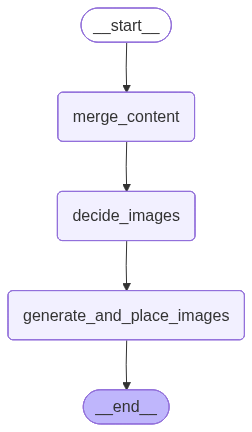

In [898]:
# build reducer subgraph
reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()

reducer_subgraph

In [899]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("sequential_workers", fanout)  # ← worker node nahi, fanout node
# g.add_node("worker", worker)  # ← yeh hata do, ab zarurat nahi
g.add_node("reducer", reducer_subgraph)

g.add_edge(START, "router")
g.add_conditional_edges(
    "router",
    lambda s: "research" if s.get("needs_research") else "orchestrator",
    {"research": "research", "orchestrator": "orchestrator"}
)
g.add_edge("research", "orchestrator")
g.add_edge("orchestrator", "sequential_workers")  # ← direct edge, no fanout
g.add_edge("sequential_workers", "reducer")
g.add_edge("reducer", END)

app = g.compile()

In [900]:

# ------------------------------------
# 10) Runner
# ------------------------------------
def run(topic: str, as_of: Optional[str] = None):
    if as_of is None:
        as_of = date.today().isoformat()

    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "as_of": as_of,
            "recency_days": 7,
            "sections": [],
            "merged_md": "",
            "md_with_placeholders": "",
            "image_specs": [],
            "final": "",
        }
    )

    return out

In [901]:
def _generate_image_bytes(prompt: str) -> bytes:
    api_key = os.environ.get("HF_API_KEY")
    if not api_key:
        raise RuntimeError("HF_API_KEY is not set.")

    # ✅ SDXL deprecated ho gaya — naya model use karo
    MODELS = [
        "black-forest-labs/FLUX.1-schnell",   # sabse fast
        "stabilityai/stable-diffusion-3.5-large-turbo",  # backup
    ]
    
    last_error = None
    for model in MODELS:
        try:
            response = requests.post(
                f"https://router.huggingface.co/hf-inference/models/{model}",
                headers={
                    "Authorization": f"Bearer {api_key}",
                    "Content-Type": "application/json"
                },
                json={"inputs": prompt},
                timeout=120,
            )
            if response.status_code == 200:
                return response.content
            last_error = f"{model}: {response.status_code} - {response.text}"
        except Exception as e:
            last_error = str(e)
    
    raise RuntimeError(f"All models failed. Last error: {last_error}")

In [902]:

out = run("state of multimodal LLMs in 2026")

ROUTER NODE VERSION 2026-06-20
TOPIC: state of multimodal LLMs in 2026
RAW RESPONSE:
{
  "needs_research": true,
  "mode": "hybrid",
  "queries": [
    "2026 multimodal large language models advancements",
    "state of multimodal LLMs 2026 benchmarks and performance",
    "latest multimodal AI models released in 2026"
  ]
}
[Worker 1] Writing: Multimodal LLM Landscape in 2026...
[Worker 1] Done ✓
[Worker 2] Writing: Benchmarking Multimodal LLMs...
[Worker 2] Done ✓
[Worker 3] Writing: Architectural Patterns for Multimodal Fusion...
[Worker 3] Done ✓
[Worker 4] Writing: Building a Minimal Multimodal Pipeline (Code Sketch)...
[Worker 4] Done ✓
[Worker 5] Writing: Performance and Cost Considerations...
[Worker 5] Done ✓
[Worker 6] Writing: Edge Cases, Failure Modes, and Debugging...
[Worker 6] Done ✓
[Worker 7] Writing: Security, Privacy, and Ethical Implications...
[Worker 7] Done ✓
